In [1]:
# mount google drive and set up paths
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from rich.traceback import install
install()

import os
from pathlib import Path
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2
import subprocess
import tempfile
from skimage import io
from setup_helper import download_repos_and_setup, DRIVE_BASE, SAM_REPO, SAM_CHECKPOINT, LIGHTGLUE_REPO, SWINIR_REPO, SWINIR_MODEL, SWINIR_MODEL_ZOO, INPUT_DIR, show_anns, show_image, show_mask_over_image, plot_masks, plot_one_mask, swinir_upscale

In [3]:
download_repos_and_setup() # run just once

SAM repo found on Drive, skipping clone.
SAM checkpoint found on Drive, skipping download.
LightGlue found on Drive, skipping clone.
SwinIR repo found on Drive, skipping clone.
SwinIR model found on Drive, skipping download.


In [4]:
from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd, ImagePreprocessor
from lightglue.superpoint import simple_nms, top_k_keypoints, sample_descriptors
from kornia.color import rgb_to_grayscale
from lightglue import viz2d

torch.set_grad_enabled(False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
class BatchedSuperPoint(SuperPoint):
    def __init__(self, **conf):
        super().__init__(**conf)
        self.preprocessor = ImagePreprocessor(**self.preprocess_conf)

    def forward(self, data: dict) -> dict:
        image = data["image"] # Original input
        device = image.device
        b, _, h, w = image.shape

        # 1. Preprocessing and Metadata inside no_grad
        with torch.no_grad():
            image_sizes = torch.tensor([w, h], device=device).float().repeat(b, 1)

            # 'img' is the resized/normalized version, 'scales' are the ratios
            img, scales = self.preprocessor(image)

        # 2. Use 'img' (the preprocessed version) for the CNN layers
        x = self.relu(self.conv1a(img))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.relu(self.conv3a(x))
        x = self.relu(self.conv3b(x))
        x = self.pool(x)
        x = self.relu(self.conv4a(x))
        x = self.relu(self.conv4b(x))

        # Compute the dense keypoint scores
        cPa = self.relu(self.convPa(x))
        scores = self.convPb(cPa)
        scores = torch.nn.functional.softmax(scores, 1)[:, :-1]
        b_proc, _, h_proc, w_proc = scores.shape
        assert b == b_proc # this must always be true
        scores = scores.permute(0, 2, 3, 1).reshape(b_proc, h_proc, w_proc, 8, 8)
        scores = scores.permute(0, 1, 3, 2, 4).reshape(b_proc, h_proc * 8, w_proc * 8)
        scores = simple_nms(scores, self.conf.nms_radius)

        if self.conf.remove_borders:
            pad = self.conf.remove_borders
            scores[:, :pad] = -1
            scores[:, :, :pad] = -1
            scores[:, -pad:] = -1
            scores[:, :, -pad:] = -1

        best_kp = torch.where(scores > self.conf.detection_threshold)

        scores = scores[best_kp]

        keypoints = [
            torch.stack(best_kp[1:3], dim=-1)[best_kp[0] == i] for i in range(b_proc)
        ]

        scores_list = [scores[best_kp[0] == i] for i in range(b_proc)]

        if self.conf.max_num_keypoints is not None:
            keypoints, scores_list = list(
                zip(
                    *[
                        top_k_keypoints(k, s, self.conf.max_num_keypoints)
                        for k, s in zip(keypoints, scores_list)
                    ]
                )
            )

        # scores_list is becomes a tuple of tensors so converting back to list
        scores_list = list(scores_list)

        # Convert (h, w) to (x, y)
        keypoints = [torch.flip(k, [1]).float() for k in keypoints]

        # Compute descriptors
        cDa = self.relu(self.convDa(x))
        descriptors = self.convDb(cDa)
        descriptors = torch.nn.functional.normalize(descriptors, p=2, dim=1)

        descriptors = [
            sample_descriptors(k[None], d[None], 8)[0]
            for k, d in zip(keypoints, descriptors)
        ]

        # 3. Final Scaling back to original resolution
        scaled_keypoints = []
        for i in range(b_proc):
            k = (keypoints[i] + 0.5) / scales[None] - 0.5
            scaled_keypoints.append(k)

        return {
            "keypoints": scaled_keypoints,
            "keypoint_scores": scores_list,
            "descriptors": [d.transpose(-1, -2).contiguous() for d in descriptors],
            "image_size": image_sizes,
            "scales": scales
        }


In [127]:
extractor = BatchedSuperPoint(max_num_keypoints=1024).eval().to(device)

matcher = LightGlue(
    features="superpoint",
    depth_confidence=-1,   # disable early stopping
    width_confidence=-1,    # disable pruning
    filter_threshold=0.05,
).eval().to(device)

In [128]:
flm_folder_path = DRIVE_BASE / 'tiles_binary_output'
tem_mask_path = Path('/content/drive/MyDrive/tem_masks_seg')
tem_img_path = tem_mask_path / 'mask_5.png'

In [129]:
from torch.utils.data import DataLoader, Dataset
class FLMDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]), cv2.IMREAD_GRAYSCALE)
        return torch.from_numpy(img).float()[None] / 255.0, str(self.paths[idx])

In [130]:
tem_image = cv2.imread(tem_img_path, cv2.IMREAD_GRAYSCALE)
flm_image_paths = sorted(Path(flm_folder_path).glob('*.png'))
dataset = FLMDataset(flm_image_paths)
batch_size = 1
loader = DataLoader(dataset, batch_size=batch_size, num_workers=2, pin_memory=True)

In [156]:
def pad_and_stack(tensor_list, fill_value=-1):
    max_len = max([t.shape[0] for t in tensor_list])
    dim = tensor_list[0].shape[-1] if tensor_list[0].ndim > 1 else None
    batch_size = len(tensor_list)

    if dim:
        out = tensor_list[0].new_full((batch_size, max_len, dim), fill_value)
    else:
        out = tensor_list[0].new_full((batch_size, max_len), fill_value)

    mask = torch.zeros(batch_size, max_len, dtype=torch.bool, device=tensor_list[0].device)

    for i, t in enumerate(tensor_list):
        out[i, :len(t)] = t
        mask[i, :len(t)] = True  # only real keypoints are True

    return out, mask

def batch_superglue_run(extractor, matcher, loader, tem_img_path):
    all_results = []

    tem_image = cv2.imread(tem_img_path, cv2.IMREAD_GRAYSCALE)

    for flm_batch_t, batch_img_paths in loader:
        current_batch_len = flm_batch_t.shape[0]
        flm_batch_t = flm_batch_t.to(device)

        tem_batch_t = torch.from_numpy(tem_image).float()[None, None].repeat(current_batch_len, 1, 1, 1).to(device) / 255.0

        with torch.no_grad():
            feats_flm = extractor({'image': flm_batch_t})
            feats_tem = extractor({'image': tem_batch_t})

        # Prepare input for LightGlue
        lg_input = {}
        for feat_idx, feats in enumerate([feats_tem, feats_flm]):
            padded_kpts, kpt_mask = pad_and_stack(feats["keypoints"])
            padded_desc, _        = pad_and_stack(feats["descriptors"])
            lg_input[f"image{feat_idx}"] = dict(
                keypoints=padded_kpts,
                descriptors=padded_desc,
                image_size=feats['image_size'],
                # mask=kpt_mask
            )

        with torch.no_grad():
            matches_out = matcher(lg_input)
        # Move results to CPU and store after unbatching
        keypoints0 = lg_input["image0"]["keypoints"] # list
        keypoints1 = lg_input["image1"]["keypoints"] # list
        matches = matches_out["matches"] # list
        scores = matches_out["scores"] # list

        for img_idx in range(current_batch_len):
            # breakpoint()
            matches01 = matches[img_idx]
            kpts0 = keypoints0[img_idx]
            kpts1 = keypoints1[img_idx]
            scr = scores[img_idx].cpu().numpy()
            m_kpts0 = kpts0[matches01[..., 0]].cpu().numpy()
            m_kpts1 = kpts1[matches01[..., 1]].cpu().numpy()
            path=batch_img_paths[img_idx]
            if len(scr) == 0:
                continue # this means no matching point was found so skip
            result = dict(
                m_kpts0=m_kpts0,
                m_kpts1=m_kpts1,
                scores=scr,
                flm_path=str(path),
                tem_path=str(tem_path)
            )

            all_results.append(result)

        # Clear VRAM for the next batch
        del flm_batch_t, feats_flm, feats_tem, matches_out

    return all_results

In [154]:
# run across all the tem_masks to find the best tem_mask and flm_mask
all_results = []
for tem_path in tem_mask_path.glob("*.png"):
    result = batch_superglue_run(extractor, matcher, loader, tem_path)
    all_results.extend(result)

In [157]:
all_results = sorted(all_results, key=lambda x: len(x['m_kpts0']), reverse=True)

In [132]:
all_results = batch_superglue_run(extractor, matcher, loader, tem_image)

In [159]:
len(all_results)

1179

In [138]:
required_path = '0001_0093.png'
for i in range(len(all_results)):
    m_kpts0 = all_results[i].m_kpts0
    m_kpts1 = all_results[i].m_kpts1
    path = all_results[i].path
    scores = all_results[i].scores
    if path.split('/')[-1] == required_path:
        break

In [134]:
all_results = sorted(all_results, key=lambda x: len(x.m_kpts0), reverse=True)

In [162]:
for i in range(10):
    r = all_results[i]
    m_kpts0 = r['m_kpts0']
    m_kpts1 = r['m_kpts1']
    tem_path = r['tem_path']
    flm_path = r['flm_path']
    transformation_matrix, inliers = cv2.estimateAffinePartial2D(
        m_kpts0,
        m_kpts1
    )
    print(len(m_kpts0), flm_path, tem_path)

61 /content/drive/MyDrive/tiles_binary_output/0001_0080.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
56 /content/drive/MyDrive/tiles_binary_output/0003_0004.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
44 /content/drive/MyDrive/tiles_binary_output/0003_0004.png /content/drive/MyDrive/tem_masks_seg/mask_0.png
41 /content/drive/MyDrive/tiles_binary_output/0000_0003.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
39 /content/drive/MyDrive/tiles_binary_output/0001_0175.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
38 /content/drive/MyDrive/tiles_binary_output/0001_0173.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
36 /content/drive/MyDrive/tiles_binary_output/0001_0096.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
35 /content/drive/MyDrive/tiles_binary_output/0001_0161.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
34 /content/drive/MyDrive/tiles_binary_output/0003_0003.png /content/drive/MyDrive/tem_masks_seg/mask_5.png
33 /content/drive/MyDrive/ti

In [166]:
m_kpts0 = all_results[0]['m_kpts0']
m_kpts1 = all_results[0]['m_kpts1']
tem_path = all_results[0]['tem_path']
flm_path = all_results[0]['flm_path']

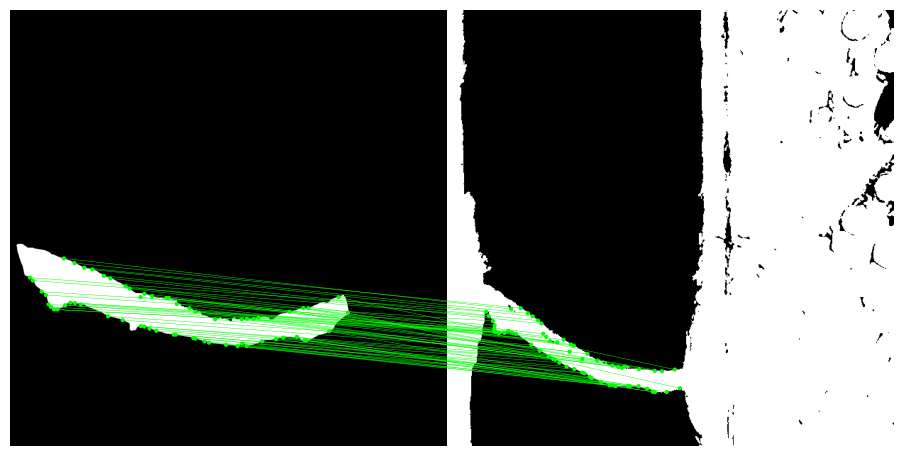

In [167]:
image0 = cv2.imread(tem_path, 0)
image1 = cv2.imread(flm_path, 0)
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.3)